In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1. LOAD DATA
df_history = pd.read_csv('synthetic_patrol_history_real_zones.csv')

# 2. DEFINE THE MATHEMATICAL MODEL
def saturation_curve(x, A, b):
    """
    The 'Law of Diminishing Returns' Formula.
    y = A * (1 - e^(-b * x))

    x: Number of Officers
    A: Maximum possible safety (e.g., 100%)
    b: 'Decay Rate' (How fast the benefit drops off)
    """
    return A * (1 - np.exp(-b * x))

# 3. CALIBRATE THE MODEL (Machine Learning)
x_data = df_history['Officers_Deployed']
y_data = df_history['Crime_Prevention_Score']

# Fit the curve
params, covariance = curve_fit(saturation_curve, x_data, y_data, p0=[100, 0.1])
A_opt, b_opt = params

print(f" Model Calibrated!")
print(f"   - Max Efficiency Ceiling (A): {A_opt:.2f}")
print(f"   - Saturation Rate (b): {b_opt:.4f}")

# 4. HELPER FUNCTION FOR OPTIMIZER
def get_marginal_benefit(current_officers):
    """
    This is the function your Resource Optimizer will call.
    It asks: "If I add one more officer, how much DOES IT HELP?"
    """
    benefit_now = saturation_curve(current_officers, A_opt, b_opt)
    benefit_next = saturation_curve(current_officers + 1, A_opt, b_opt)

    gain = benefit_next - benefit_now
    return gain

# 5. DEMONSTRATION
print("\n Impact Analysis (Proof of Diminishing Returns):")
print("-" * 50)
print(f"{'Officer #':<10} | {'Total Safety':<15} | {'Benefit of Adding Next Officer':<30}")
print("-" * 50)

for n in [1, 5, 10, 20, 30]:
    gain = get_marginal_benefit(n)
    score = saturation_curve(n, A_opt, b_opt)
    print(f"{n:<10} | {score:.2f}%{'':<8} | +{gain:.2f}% safety boost")

 Model Calibrated!
   - Max Efficiency Ceiling (A): 99.95
   - Saturation Rate (b): 0.0815

 Impact Analysis (Proof of Diminishing Returns):
--------------------------------------------------
Officer #  | Total Safety    | Benefit of Adding Next Officer
--------------------------------------------------
1          | 7.82%         | +7.21% safety boost
5          | 33.46%         | +5.21% safety boost
10         | 55.72%         | +3.46% safety boost
20         | 80.38%         | +1.53% safety boost
30         | 91.29%         | +0.68% safety boost


In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import json
import os

class DiminishingReturnsModel:
    def __init__(self, model_file="diminishing_returns_params.json"):
        self.model_file = model_file
        # Default Parameters (Fallback if no training happens)
        self.A = 100.0  # Max Efficiency Ceiling
        self.b = 0.1    # Default Decay Rate

        # Try to load existing "learned" parameters
        self.load_parameters()

    def saturation_curve(self, x, A, b):
        """ The mathematical core: y = A * (1 - e^(-b*x)) """
        return A * (1 - np.exp(-b * x))

    def train_and_update(self, data_path):
        """
        The 'Continuous Learning' Function.
        Reads the latest history file and re-calculates A and b.
        """
        print(f"🔄 Reading data from {data_path}...")
        try:
            df = pd.read_csv(data_path)
            x_data = df['Officers_Deployed']
            y_data = df['Crime_Prevention_Score']

            # CURVE FITTING
            # We constrain b to be positive
            params, _ = curve_fit(
                self.saturation_curve,
                x_data,
                y_data,
                p0=[100, 0.1],
                bounds=([80, 0.001], [100, 1.0])
            )

            # Update internal knowledge
            self.A, self.b = params
            print(f"✅ Model Updated! New Params -> Max Efficiency (A): {self.A:.2f}, Decay (b): {self.b:.4f}")

            # Save to disk so we remember this tomorrow
            self.save_parameters()
            return True

        except Exception as e:
            print(f"⚠️ Update Failed: {e}")
            return False

    def get_marginal_benefit(self, current_officers):
        """ Calculates how much the NEXT officer adds to safety. """
        benefit_now = self.saturation_curve(current_officers, self.A, self.b)
        benefit_next = self.saturation_curve(current_officers + 1, self.A, self.b)
        return benefit_next - benefit_now

    def save_parameters(self):
        """ Persist learned knowledge to a JSON file """
        data = {"A": self.A, "b": self.b}
        with open(self.model_file, 'w') as f:
            json.dump(data, f)
        print("💾 Knowledge saved to disk.")

    def load_parameters(self):
        """ Load learned knowledge from JSON """
        if os.path.exists(self.model_file):
            with open(self.model_file, 'r') as f:
                data = json.load(f)
                self.A = data.get("A", 100.0)
                self.b = data.get("b", 0.1)
            print(f"📂 Loaded saved parameters: A={self.A:.2f}, b={self.b:.4f}")

#  SIMULATION: HOW IT UPDATES OVER TIME

# A. Initialize the System
print("--- SYSTEM STARTUP ---")
dr_model = DiminishingReturnsModel()


print("\n--- PHASE 1: INITIAL TRAINING ---")
# Ensure the file exists
if not os.path.exists('synthetic_patrol_history_real_zones.csv'):
    officers = np.random.randint(1, 40, 50)
    scores = 100 * (1 - np.exp(-0.1 * officers)) + np.random.normal(0, 2, 50)
    pd.DataFrame({'Officers_Deployed': officers, 'Crime_Prevention_Score': scores}).to_csv('synthetic_patrol_history_real_zones.csv', index=False)

dr_model.train_and_update('synthetic_patrol_history_real_zones.csv')

# Test Prediction
officers_now = 10
benefit = dr_model.get_marginal_benefit(officers_now)
print(f"TEST: Adding the 11th officer gives +{benefit:.2f}% safety boost.")


# C. Phase 2: NEW DATA ARRIVES (Simulating future updates)
print("\n--- PHASE 2: NEW DATA ARRIVES (Month 2) ---")
print("ℹ️  Scenario: Police got new drones. They are MORE effective now.")
print("    Generating new history file...")

# Generate 'New' data where efficiency is HIGHER (b is larger, e.g., 0.15)
new_officers = np.random.randint(1, 40, 50)
# Note the -0.15 here (faster saturation = better tech)
new_scores = 100 * (1 - np.exp(-0.15 * new_officers)) + np.random.normal(0, 2, 50)

df_new = pd.DataFrame({'Officers_Deployed': new_officers, 'Crime_Prevention_Score': new_scores})
df_new.to_csv('synthetic_patrol_history_UPDATED.csv', index=False)

# D. Trigger the Update
print("🚀 Triggering System Update...")
dr_model.train_and_update('synthetic_patrol_history_UPDATED.csv')

# Test Prediction Again
new_benefit = dr_model.get_marginal_benefit(officers_now)
print(f"TEST: Adding the 11th officer now gives +{new_benefit:.2f}% safety boost.")
print(f"ANALYSIS: Previous Benefit: {benefit:.2f} vs New Benefit: {new_benefit:.2f}")
if new_benefit < benefit:
    print("✅ Result: Because police are more efficient, the 'Marginal Benefit' of adding extra officers drops faster.")
    print("   The system will now allocate FEWER officers to achieve the same safety, saving resources!")

--- SYSTEM STARTUP ---

--- PHASE 1: INITIAL TRAINING ---
🔄 Reading data from synthetic_patrol_history_real_zones.csv...
✅ Model Updated! New Params -> Max Efficiency (A): 99.95, Decay (b): 0.0815
💾 Knowledge saved to disk.
TEST: Adding the 11th officer gives +3.46% safety boost.

--- PHASE 2: NEW DATA ARRIVES (Month 2) ---
ℹ️  Scenario: Police got new drones. They are MORE effective now.
    Generating new history file...
🚀 Triggering System Update...
🔄 Reading data from synthetic_patrol_history_UPDATED.csv...
✅ Model Updated! New Params -> Max Efficiency (A): 100.00, Decay (b): 0.1468
💾 Knowledge saved to disk.
TEST: Adding the 11th officer now gives +3.15% safety boost.
ANALYSIS: Previous Benefit: 3.46 vs New Benefit: 3.15
✅ Result: Because police are more efficient, the 'Marginal Benefit' of adding extra officers drops faster.
   The system will now allocate FEWER officers to achieve the same safety, saving resources!


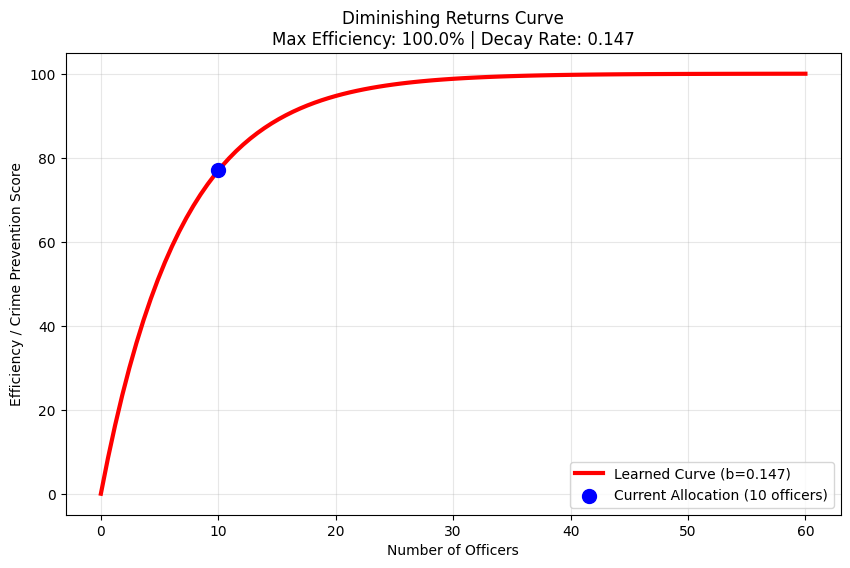

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Generate data points based on your TRAINED model
# We define a range of officers (0 to 60) to see the full curve
x_range = np.linspace(0, 60, 100)

# We use the parameters stored inside your 'dr_model' object
# y = A * (1 - e^(-b * x))
y_fitted = dr_model.A * (1 - np.exp(-dr_model.b * x_range))

# 2. Plotting
plt.figure(figsize=(10, 6))

# Draw the curve
plt.plot(x_range, y_fitted, color='red', linewidth=3, label=f'Learned Curve (b={dr_model.b:.3f})')

# Add a marker for "Current Status" (e.g., if you have 10 officers)
current_officers = 10
current_score = dr_model.saturation_curve(current_officers, dr_model.A, dr_model.b)
plt.scatter(current_officers, current_score, color='blue', s=100, zorder=5, label=f'Current Allocation ({current_officers} officers)')

# Formatting
plt.title(f'Diminishing Returns Curve\nMax Efficiency: {dr_model.A:.1f}% | Decay Rate: {dr_model.b:.3f}')
plt.xlabel('Number of Officers')
plt.ylabel('Efficiency / Crime Prevention Score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()